# Intermediate Report - BertChineseEmbSlimCNNlstmBert Evaluation

This notebook evaluates the intermediate model from `interm_report_bert_cnn_rnn_20251112_014948`.

**Data Range**: Training progress up to Epoch 7, Iteration 3 (all 3 validations completed for epoch 7)

Features:
- Chinese font support for displaying punctuation marks
- Training progress visualization
- Model evaluation (if model file available)


In [19]:
import sys
import os

# Add test_replication to path to import models
test_replication_path = '../test_replication'
if os.path.exists(test_replication_path):
    abs_path = os.path.abspath(test_replication_path)
    sys.path.insert(0, abs_path)
    print(f"✓ Added to path: {abs_path}")
else:
    cwd = os.getcwd()
    if 'Bert-CNN-RNN' in cwd:
        parent = os.path.dirname(cwd)
        test_replication_path = os.path.join(parent, 'test_replication')
        if os.path.exists(test_replication_path):
            sys.path.insert(0, test_replication_path)
            print(f"✓ Added to path: {test_replication_path}")
        else:
            print(f"⚠ Warning: Could not find test_replication folder")

import pandas as pd
import numpy as np
from transformers import BertTokenizer
import torch
from torch import nn
%matplotlib inline
import json
from tqdm import tqdm
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Import model from test_replication
from model import BertChineseEmbSlimCNNlstmBert

# Import data utilities (use Bert-CNN-RNN version)
from data_1_to_1 import load_file, preprocess_data, create_data_loader

# Configure matplotlib to support Chinese characters
def setup_chinese_font():
    """Setup matplotlib to use a font that supports Chinese characters"""
    chinese_fonts = [
        # macOS
        'PingFang SC', 'STHeiti', 'Heiti SC', 'Arial Unicode MS',
        # Linux
        'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei',
        # Windows
        'Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi'
    ]
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    font_found = None
    font_prop = None
    for font_name in chinese_fonts:
        if font_name in available_fonts:
            font_found = font_name
            for f in fm.fontManager.ttflist:
                if f.name == font_name:
                    try:
                        font_prop = fm.FontProperties(fname=f.fname, size=10)
                    except:
                        font_prop = fm.FontProperties(family=font_name, size=10)
                    break
            if font_prop:
                break
    
    if font_found:
        plt.rcParams['font.sans-serif'] = [font_found] + [f for f in plt.rcParams['font.sans-serif'] if f != font_found]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set(font=font_found)
        print(f"✓ Using Chinese font: {font_found}")
        return font_found, font_prop
    else:
        print("⚠ Warning: No Chinese font found. Chinese characters may not display correctly.")
        return None, None

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Setup Chinese font
chinese_font_name, chinese_font_prop = setup_chinese_font()

print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


✓ Added to path: /Users/r3ttalynn/Documents/GitHub/jhu-mt-hw/test_replication
✓ Using Chinese font: Arial Unicode MS
Using device: cpu


## Model Path Configuration


In [20]:
# Intermediate report model path
model_path = '../test_replication/outputs/interm_report_bert_cnn_rnn_20251112_014948'
hyperparameters_path = os.path.join(model_path, 'hyperparameters.json')
progress_csv_path = os.path.join(model_path, 'progress.csv')
model_file_path = os.path.join(model_path, 'model')  # Check if model file exists

print(f"Model directory: {model_path}")
print(f"Hyperparameters: {hyperparameters_path}")
print(f"Progress CSV: {progress_csv_path}")
print(f"Model file: {model_file_path} (exists: {os.path.exists(model_file_path)})")


Model directory: ../test_replication/outputs/interm_report_bert_cnn_rnn_20251112_014948
Hyperparameters: ../test_replication/outputs/interm_report_bert_cnn_rnn_20251112_014948/hyperparameters.json
Progress CSV: ../test_replication/outputs/interm_report_bert_cnn_rnn_20251112_014948/progress.csv
Model file: ../test_replication/outputs/interm_report_bert_cnn_rnn_20251112_014948/model (exists: True)


## Load Hyperparameters


In [21]:
# Load hyperparameters
with open(hyperparameters_path, 'r', encoding='utf-8') as f:
    hyperparams = json.load(f)

seq_len = hyperparams.get('seq_len', 200)
dropout = hyperparams.get('dropout', 0.1)
punctuation_enc = hyperparams.get('punctuation_enc', {
    'O': 0,
    '，': 1,
    '。': 2,
    '？': 3
})
output_size = len(punctuation_enc)

print("Hyperparameters:")
print(f"  Sequence Length: {seq_len}")
print(f"  Dropout: {dropout}")
print(f"  Output Size: {output_size}")
print(f"  Punctuation Encoding: {punctuation_enc}")
print(f"  Epochs: {hyperparams.get('epochs', 'N/A')}")
print(f"  Batch Size: {hyperparams.get('batch_size', 'N/A')}")
print(f"  Learning Rate: {hyperparams.get('learning_rate', 'N/A')}")

hyperparams


Hyperparameters:
  Sequence Length: 200
  Dropout: 0.1
  Output Size: 4
  Punctuation Encoding: {'O': 0, '，': 1, '。': 2, '？': 3}
  Epochs: 7
  Batch Size: 40
  Learning Rate: 1e-05


{'seq_len': 200,
 'dropout': 0.1,
 'epochs': 7,
 'batch_size': 40,
 'learning_rate': 1e-05,
 'iterations': 3,
 'max_train_lines': 150000,
 'max_valid_lines': 50000,
 'punctuation_enc': {'O': 0, '，': 1, '。': 2, '？': 3},
 'class_weights': {'O': 1.0,
  '，': 24.930660247802734,
  '。': 23.184886932373047,
  '？': 313.0748291015625}}

## Load Training Progress (Up to Epoch 7, Iteration 3)


In [22]:
# Load progress CSV
progress_full = pd.read_csv(progress_csv_path, delimiter=';')

# Filter to epoch <= 7, and if epoch == 7, only iteration <= 3
progress = progress_full[
    (progress_full['epoch'] < 7) | 
    ((progress_full['epoch'] == 7) & (progress_full['iteration'] <= 3))
].copy()

print(f"Total rows in progress.csv: {len(progress_full)}")
print(f"Filtered rows (up to epoch 7, iteration 3): {len(progress)}")
print(f"\nEpoch range: {progress['epoch'].min()} to {progress['epoch'].max()}")
print(f"Last epoch iterations: {progress[progress['epoch'] == progress['epoch'].max()]['iteration'].tolist()}")

display(progress.head(10))
print("\n...")
display(progress.tail(10))


Total rows in progress.csv: 45
Filtered rows (up to epoch 7, iteration 3): 21

Epoch range: 1 to 7
Last epoch iterations: [1, 2, 3]


,time,epoch,iteration,training_loss,val_loss,accuracy,f1_O,f1_，,f1_。,f1_？
0,2025-11-12 01:52:56,1,1,1.3766,1.2938,0.4390,0.6070,0.0758,0.1188,0.0427
1,2025-11-12 01:56:02,1,2,1.2905,1.1826,0.5272,0.6919,0.1131,0.1758,0.0602
2,2025-11-12 01:58:08,1,3,1.1931,1.0944,0.7286,0.8541,0.1506,0.2664,0.0643
3,2025-11-12 02:01:16,2,1,1.0877,0.9659,0.7523,0.8695,0.2103,0.3110,0.0972
4,2025-11-12 02:04:23,2,2,0.9599,0.8601,0.8431,0.9265,0.2277,0.4247,0.1442
5,2025-11-12 02:06:26,2,3,0.8579,0.7745,0.7817,0.8890,0.2353,0.4393,0.0782
6,2025-11-12 02:09:19,3,1,0.7824,0.7020,0.8404,0.9237,0.2199,0.4958,0.1704
7,2025-11-12 02:12:19,3,2,0.6945,0.6397,0.8495,0.9299,0.2684,0.5415,0.1709
8,2025-11-12 02:14:28,3,3,0.6769,0.6237,0.8260,0.9161,0.1926,0.5133,0.1380
9,2025-11-12 02:17:28,4,1,0.6233,0.5742,0.8736,0.9419,0.2798,0.6013,0.2729



...


,time,epoch,iteration,training_loss,val_loss,accuracy,f1_O,f1_，,f1_。,f1_？
11,2025-11-12 02:22:49,4,3,0.5774,0.5453,0.8596,0.9328,0.2578,0.6111,0.3179
12,2025-11-12 02:25:52,5,1,0.5461,0.5287,0.8679,0.9382,0.2931,0.6174,0.2428
13,2025-11-12 02:28:59,5,2,0.5392,0.5304,0.8591,0.9325,0.2493,0.5910,0.3428
14,2025-11-12 02:31:08,5,3,0.4897,0.5102,0.8822,0.9456,0.3071,0.6267,0.3890
15,2025-11-12 02:34:14,6,1,0.4902,0.4966,0.8658,0.9356,0.2883,0.6286,0.3458
16,2025-11-12 02:37:15,6,2,0.4708,0.5016,0.8755,0.9411,0.2946,0.6266,0.3807
17,2025-11-12 02:39:20,6,3,0.4254,0.4970,0.8765,0.9415,0.3152,0.6372,0.4134
18,2025-11-12 02:42:15,7,1,0.4312,0.4861,0.8787,0.9427,0.3149,0.6319,0.3995
19,2025-11-12 02:45:09,7,2,0.4291,0.4988,0.8884,0.9481,0.3284,0.6385,0.4834
20,2025-11-12 02:47:15,7,3,0.4184,0.4804,0.8741,0.9395,0.3135,0.6498,0.4331


## Training Progress Visualization


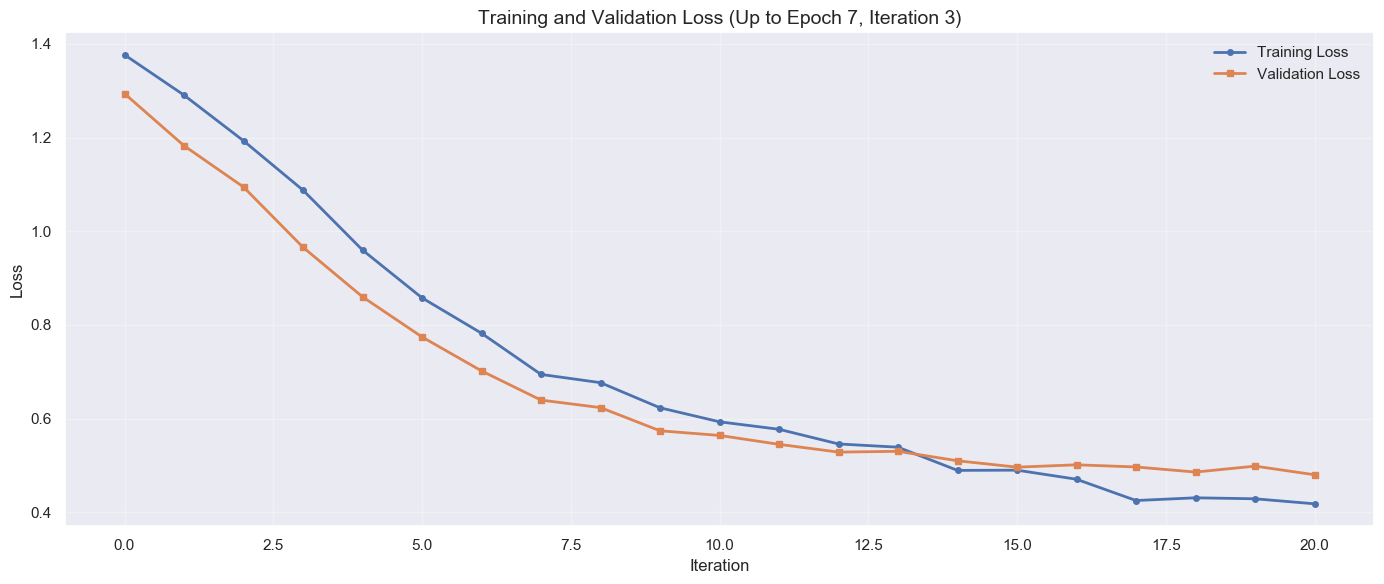

In [23]:
# Plot training and validation loss
fig, ax = plt.subplots(figsize=(14, 6))

# Get column names (handle different naming conventions)
train_col = 'training_loss' if 'training_loss' in progress.columns else 'training loss'
val_col = 'val_loss' if 'val_loss' in progress.columns else 'loss'

if train_col in progress.columns and val_col in progress.columns:
    ax.plot(progress[train_col], label='Training Loss', linewidth=2, marker='o', markersize=4)
    ax.plot(progress[val_col], label='Validation Loss', linewidth=2, marker='s', markersize=4)
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training and Validation Loss (Up to Epoch 7, Iteration 3)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ Columns not found: train_col={train_col}, val_col={val_col}")
    print(f"Available columns: {progress.columns.tolist()}")


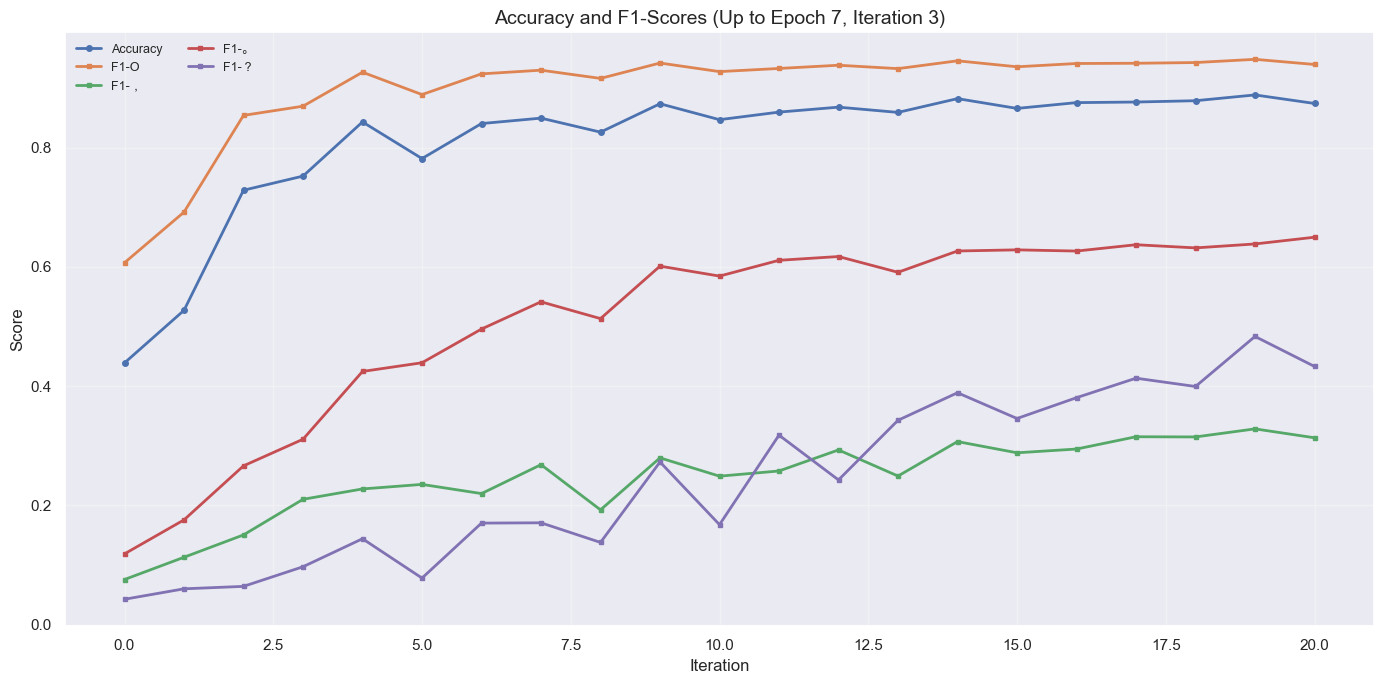

In [24]:
# Plot accuracy and F1-scores
fig, ax = plt.subplots(figsize=(14, 7))

if 'accuracy' in progress.columns:
    ax.plot(progress['accuracy'], label='Accuracy', linewidth=2, marker='o', markersize=4)

# Plot F1-scores for each punctuation class
f1_cols = [col for col in progress.columns if col.startswith('f1_')]
for col in f1_cols:
    label = col.replace('f1_', '')
    ax.plot(progress[col], label=f'F1-{label}', linewidth=2, marker='s', markersize=3)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Accuracy and F1-Scores (Up to Epoch 7, Iteration 3)', fontsize=14, fontweight='bold')
if chinese_font_name:
    font_prop_legend = fm.FontProperties(family=chinese_font_name, size=9)
    ax.legend(fontsize=9, loc='best', prop=font_prop_legend, ncol=2)
else:
    ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary Statistics


In [25]:
# Summary statistics
print("=" * 60)
print("Training Progress Summary (Up to Epoch 7, Iteration 3)")
print("=" * 60)

if 'accuracy' in progress.columns:
    print(f"\nFinal Accuracy: {progress['accuracy'].iloc[-1]:.4f}")
    print(f"Best Accuracy: {progress['accuracy'].max():.4f} (at iteration {progress['accuracy'].idxmax() + 1})")

train_col = 'training_loss' if 'training_loss' in progress.columns else 'training loss'
val_col = 'val_loss' if 'val_loss' in progress.columns else 'loss'

if train_col in progress.columns:
    print(f"\nFinal Training Loss: {progress[train_col].iloc[-1]:.4f}")
    print(f"Final Validation Loss: {progress[val_col].iloc[-1]:.4f}")
    print(f"Best Validation Loss: {progress[val_col].min():.4f} (at iteration {progress[val_col].idxmin() + 1})")

print("\nFinal F1-Scores:")
f1_cols = [col for col in progress.columns if col.startswith('f1_')]
for col in f1_cols:
    label = col.replace('f1_', '')
    final_f1 = progress[col].iloc[-1]
    best_f1 = progress[col].max()
    best_iter = progress[col].idxmax() + 1
    print(f"  {label}: Final={final_f1:.4f}, Best={best_f1:.4f} (iter {best_iter})")

print("\n" + "=" * 60)


Training Progress Summary (Up to Epoch 7, Iteration 3)

Final Accuracy: 0.8741
Best Accuracy: 0.8884 (at iteration 20)

Final Training Loss: 0.4184
Final Validation Loss: 0.4804
Best Validation Loss: 0.4804 (at iteration 21)

Final F1-Scores:
  O: Final=0.9395, Best=0.9481 (iter 20)
  ，: Final=0.3135, Best=0.3284 (iter 20)
  。: Final=0.6498, Best=0.6498 (iter 21)
  ？: Final=0.4331, Best=0.4834 (iter 20)



## Model Evaluation (if model file exists)


In [26]:
# Check if model file exists
if os.path.exists(model_file_path):
    print("✓ Model file found. Loading model for evaluation...")
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Load tokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-chinese', do_lower_case=True)
    print("✓ Tokenizer loaded")
    
    # Initialize model
    model = BertChineseEmbSlimCNNlstmBert(seq_len, output_size, dropout, None).to(device)
    model.load_state_dict(torch.load(model_file_path, map_location=device))
    model.eval()
    print("✓ Model loaded")
    
    # Load test data
    data_test = load_file('data/zh_iwslt/test_valid')
    data_test_asr = load_file('data/zh_iwslt/test_valid')
    
    print(f"\nTest samples: {len(data_test)}")
    
    # Preprocess data
    X_test, y_test = preprocess_data(data_test, tokenizer, punctuation_enc, seq_len)
    X_test_asr, y_test_asr = preprocess_data(data_test_asr, tokenizer, punctuation_enc, seq_len)
    
    print(f"Test sequences: {X_test.shape[0]}")
    print(f"Test ASR sequences: {X_test_asr.shape[0]}")
    
else:
    print("⚠ Model file not found. Skipping model evaluation.")
    print("  Only training progress visualization is available.")


✓ Model file found. Loading model for evaluation...
✓ Tokenizer loaded
✓ Model loaded

Test samples: 150859
Test sequences: 754
Test ASR sequences: 754


In [ ]:
# Model evaluation functions
if os.path.exists(model_file_path):
    def predictions(model, data_loader, device):
        """Get predictions from a model"""
        y_pred = []
        y_true = []
        model.eval()
        for inputs, labels in tqdm(data_loader, total=len(data_loader), desc="Evaluating"):
            with torch.no_grad():
                inputs, labels = inputs.to(device), labels.to(device)
                output = model(inputs)
                y_pred += list(output.argmax(dim=1).cpu().data.numpy().flatten())
                y_true += list(labels.cpu().data.numpy().flatten())
        return y_pred, y_true

    def evaluation(y_pred, y_test):
        """Calculate evaluation metrics"""
        precision, recall, f1, _ = metrics.precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[1, 2, 3], zero_division=0)
        overall = metrics.precision_recall_fscore_support(
            y_test, y_pred, average='macro', labels=[1, 2, 3], zero_division=0)
        result = pd.DataFrame(
            np.array([precision, recall, f1]), 
            columns=['，', '。', '？'], 
            index=['Precision', 'Recall', 'F1']
        )
        result['OVERALL'] = overall[:3]
        return result

    # Evaluate on test set
    batch_size = 200
    data_loader_test = create_data_loader(X_test, y_test, False, batch_size)
    
    print("Evaluating on test set...")
    y_pred_test, y_true_test = predictions(model, data_loader_test, device)
    eval_test = evaluation(y_pred_test, y_true_test)
    
    print("\nTest Set Results:")
    display(eval_test)
    
    # Evaluate on ASR test set
    data_loader_test_asr = create_data_loader(X_test_asr, y_test_asr, False, batch_size)
    
    print("\nEvaluating on ASR test set...")
    y_pred_test_asr, y_true_test_asr = predictions(model, data_loader_test_asr, device)
    eval_test_asr = evaluation(y_pred_test_asr, y_true_test_asr)
    
    print("\nASR Test Set Results:")
    display(eval_test_asr)
    
    # Bar charts for test set results
    print("\n" + "="*60)
    print("Bar Chart Visualizations - Test Set")
    print("="*60)
    
    # Bar chart 1: Comparison for each punctuation class
    for col in eval_test.columns:
        if col == 'OVERALL':
            continue
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        metrics_data = {
            'Precision': eval_test[col]['Precision'],
            'Recall': eval_test[col]['Recall'],
            'F1-Score': eval_test[col]['F1']
        }
        
        x = np.arange(len(metrics_data))
        width = 0.6
        bars = ax.bar(x, list(metrics_data.values()), width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
        
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title(f'{col} Performance (Test Set)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(list(metrics_data.keys()))
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, metrics_data.values()):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Set font for title if Chinese font is available
        if chinese_font_name and col in ['，', '。', '？']:
            font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=14)
            ax.set_title(f'{col} Performance (Test Set)', fontsize=14, fontweight='bold', 
                        fontproperties=font_prop_with_size)
        
        plt.tight_layout()
        plt.show()
    
    # Bar chart 2: Overall comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    overall_data = {
        'Precision': eval_test['OVERALL']['Precision'],
        'Recall': eval_test['OVERALL']['Recall'],
        'F1-Score': eval_test['OVERALL']['F1']
    }
    
    x = np.arange(len(overall_data))
    width = 0.6
    bars = ax.bar(x, list(overall_data.values()), width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Overall Performance (Test Set)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(overall_data.keys()))
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, overall_data.values()):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Bar chart 3: All punctuation classes side by side for each metric
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = ['Precision', 'Recall', 'F1']
    punctuation_classes = ['，', '。', '？']
    colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = [eval_test[punc][metric] for punc in punctuation_classes]
        bars = ax.bar(range(len(punctuation_classes)), values, color=colors_list, alpha=0.8)
        
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title(f'{metric} by Punctuation Class', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(punctuation_classes)))
        if chinese_font_name:
            font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=12)
            ax.set_xticklabels(punctuation_classes, fontproperties=font_prop_with_size)
        else:
            ax.set_xticklabels(punctuation_classes)
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Bar charts for ASR test set
    print("\n" + "="*60)
    print("Bar Chart Visualizations - ASR Test Set")
    print("="*60)
    
    # Same charts for ASR set
    for col in eval_test_asr.columns:
        if col == 'OVERALL':
            continue
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        metrics_data = {
            'Precision': eval_test_asr[col]['Precision'],
            'Recall': eval_test_asr[col]['Recall'],
            'F1-Score': eval_test_asr[col]['F1']
        }
        
        x = np.arange(len(metrics_data))
        width = 0.6
        bars = ax.bar(x, list(metrics_data.values()), width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
        
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title(f'{col} Performance (ASR Test Set)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(list(metrics_data.keys()))
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, metrics_data.values()):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Set font for title if Chinese font is available
        if chinese_font_name and col in ['，', '。', '？']:
            font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=14)
            ax.set_title(f'{col} Performance (ASR Test Set)', fontsize=14, fontweight='bold', 
                        fontproperties=font_prop_with_size)
        
        plt.tight_layout()
        plt.show()
    
    # Overall ASR comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    overall_asr_data = {
        'Precision': eval_test_asr['OVERALL']['Precision'],
        'Recall': eval_test_asr['OVERALL']['Recall'],
        'F1-Score': eval_test_asr['OVERALL']['F1']
    }
    
    x = np.arange(len(overall_asr_data))
    width = 0.6
    bars = ax.bar(x, list(overall_asr_data.values()), width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Overall Performance (ASR Test Set)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(overall_asr_data.keys()))
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, overall_asr_data.values()):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # All punctuation classes side by side for ASR
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = [eval_test_asr[punc][metric] for punc in punctuation_classes]
        bars = ax.bar(range(len(punctuation_classes)), values, color=colors_list, alpha=0.8)
        
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title(f'{metric} by Punctuation Class (ASR)', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(punctuation_classes)))
        if chinese_font_name:
            font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=12)
            ax.set_xticklabels(punctuation_classes, fontproperties=font_prop_with_size)
        else:
            ax.set_xticklabels(punctuation_classes)
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


Evaluating on test set...


Evaluating: 100%|██████████| 4/4 [00:42<00:00, 10.53s/it]


Test Set Results:


,，,。,？,OVERALL
Precision,0.224891,0.572069,0.295500,0.364154
Recall,0.665386,0.795017,0.856031,0.772145
F1,0.336164,0.665363,0.439341,0.480289



Evaluating on ASR test set...


Evaluating: 100%|██████████| 4/4 [00:43<00:00, 10.78s/it]


ASR Test Set Results:


,，,。,？,OVERALL
Precision,0.224891,0.572069,0.295500,0.364154
Recall,0.665386,0.795017,0.856031,0.772145
F1,0.336164,0.665363,0.439341,0.480289
